In [1]:
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch.optim as optim
import torch.nn as nn
import torch 

La médiane est une mesure statistique qui représente la valeur centrale d'un ensemble de données triées. Pour comprendre la médiane, il est important de savoir que les données doivent être ordonnées par ordre croissant ou décroissant avant de la calculer.

La médiane est utile pour résumer la tendance centrale d'un ensemble de données, en particulier lorsque les données sont susceptibles de comporter des valeurs aberrantes (valeurs extrêmes qui diffèrent grandement des autres observations).

Pour calculer la médiane :
1. Triez les données par ordre croissant ou décroissant (du plus petit au plus grand ou vice versa).
2. Si le nombre d'observations (n) est impair, la médiane est la valeur au milieu de l'ensemble de données.
3. Si le nombre d'observations (n) est pair, la médiane est calculée en prenant la moyenne des deux valeurs du milieu.

Exemple avec un ensemble de données ordonnées :

```
Données : 3, 5, 6, 7, 9, 12, 15
```

Comme le nombre d'observations (n) est impair (7), la médiane est simplement la valeur du milieu, soit 7.

Exemple avec un autre ensemble de données ordonnées :

```
Données : 2, 5, 6, 8, 9, 11
```

Comme le nombre d'observations (n) est pair (6), la médiane est calculée en prenant la moyenne des deux valeurs du milieu (6 et 8) :

```
Médiane = (6 + 8) / 2 = 7
```

La médiane est utile pour réduire l'impact des valeurs aberrantes sur les données, car elle ne dépend que des valeurs centrales. Elle est souvent utilisée en combinaison avec la moyenne (moyenne arithmétique) pour mieux comprendre la distribution des données dans un ensemble.

In [2]:
# Charger les données depuis le fichier CSV
# Et le nottoyage de données

chemin_vers_le_fichier = 'train.csv'

donnees = pd.read_csv(chemin_vers_le_fichier, decimal=',', sep=";", na_values=["#VALEUR!"], index_col="time")
#On remplace les cellules avec des valeurs non valides par NaN

donnees.index = pd.to_datetime(donnees.index, format='%d/%m/%Y %H:%M')
#On choisis la date en tant qu'index et on convertis au format spéciale

print(donnees.info())
#recap de la data

assert donnees.dtypes.equals(pd.Series(dict(zip(donnees.columns,["float64"]*len(donnees.columns)))))

print("\n")

donnees.isna().sum()

#Traitement des NaN on les remplace par la mediane de la collonne. La médiane est une mesure statistique qui représente la valeur centrale d'un ensemble de données triées

chosen_strategy = 'median' # "mean" / "constant" / "most_frequent"

for col in donnees.columns:
    imp_mean = SimpleImputer(missing_values=np.nan, strategy='median')
    donnees[col] = imp_mean.fit_transform(donnees[[col]]).squeeze()

assert (donnees.isna().sum(axis=0).sum() == 0)

print("\n")

donnees.isna().sum()
#Plus de valeur NaN chouette !!!! hihihihihihihihihihihihihihi

donnees = donnees.sample(n=100236, random_state=12).copy()

print(donnees.info())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 297316 entries, 2022-01-01 00:00:00 to 2022-09-25 12:15:00
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Amb temp °C                   297237 non-null  float64
 1   Comp inlet temp °C            297252 non-null  float64
 2   amb pressure                  297307 non-null  float64
 3   HR %                          297288 non-null  float64
 4   C/H                           297271 non-null  float64
 5   Network Frequency (Hz)        296954 non-null  float64
 6   Lower Heating Value (Wh/Nm3)  296798 non-null  float64
 7   EOH (h)                       295737 non-null  float64
 8   DP filtre                     297288 non-null  float64
 9   CTRL anti givrage             297254 non-null  float64
 10  IGV %                         297075 non-null  float64
 11  Net Power (MW)                296941 non-null  float64
dtypes: float64

In [3]:

# Calculer la taille des deux parties x1 et x2
taille_x1 = int(3 * len(donnees) / 4)
taille_x2 = len(donnees) - taille_x1

print(len(donnees),taille_x1,taille_x2)
# Diviser le DataFrame en deux parties x1 et x2
x1 = donnees.iloc[:taille_x1]
x2 = donnees.iloc[taille_x1:]

donnees = x1

donnees_test = x2

print(donnees.info())

100236 75177 25059
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 75177 entries, 2022-05-25 13:54:00 to 2022-05-17 05:38:00
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Amb temp °C                   75177 non-null  float64
 1   Comp inlet temp °C            75177 non-null  float64
 2   amb pressure                  75177 non-null  float64
 3   HR %                          75177 non-null  float64
 4   C/H                           75177 non-null  float64
 5   Network Frequency (Hz)        75177 non-null  float64
 6   Lower Heating Value (Wh/Nm3)  75177 non-null  float64
 7   EOH (h)                       75177 non-null  float64
 8   DP filtre                     75177 non-null  float64
 9   CTRL anti givrage             75177 non-null  float64
 10  IGV %                         75177 non-null  float64
 11  Net Power (MW)                75177 non-null  float64
dtypes: flo

Amb temp °C
time
2022-05-25 13:54:00    17.670558
2022-05-17 18:33:00    22.840895
2022-05-20 15:12:00    16.386539
2022-08-11 01:43:00    22.094704
2022-01-23 09:26:00     4.768120
                         ...    
2022-06-24 20:33:00    23.941195
2022-05-09 15:24:00    21.995255
2022-09-09 04:26:00    12.796643
2022-06-21 06:05:00    15.194421
2022-05-17 05:38:00    14.048804
Name: Amb temp °C, Length: 75177, dtype: float64 time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64


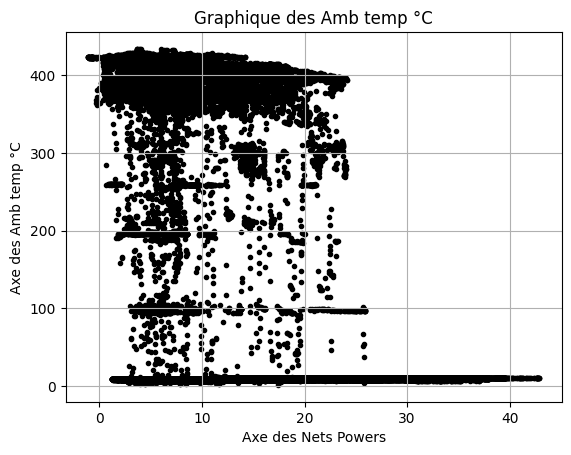

Comp inlet temp °C
time
2022-05-25 13:54:00    23.769070
2022-05-17 18:33:00    24.780251
2022-05-20 15:12:00    20.413162
2022-08-11 01:43:00    24.089632
2022-01-23 09:26:00     4.808198
                         ...    
2022-06-24 20:33:00    27.331808
2022-05-09 15:24:00    24.163029
2022-09-09 04:26:00    23.023655
2022-06-21 06:05:00    22.586338
2022-05-17 05:38:00    21.714924
Name: Comp inlet temp °C, Length: 75177, dtype: float64 time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64


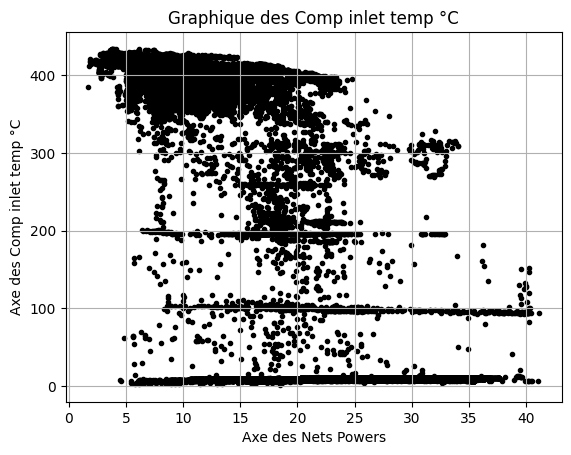

amb pressure
time
2022-05-25 13:54:00     989.578683
2022-05-17 18:33:00     996.377450
2022-05-20 15:12:00     990.060250
2022-08-11 01:43:00     991.438241
2022-01-23 09:26:00     996.054574
                          ...     
2022-06-24 20:33:00     995.881051
2022-05-09 15:24:00     995.281380
2022-09-09 04:26:00     995.565377
2022-06-21 06:05:00     993.209847
2022-05-17 05:38:00    1000.302315
Name: amb pressure, Length: 75177, dtype: float64 time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64


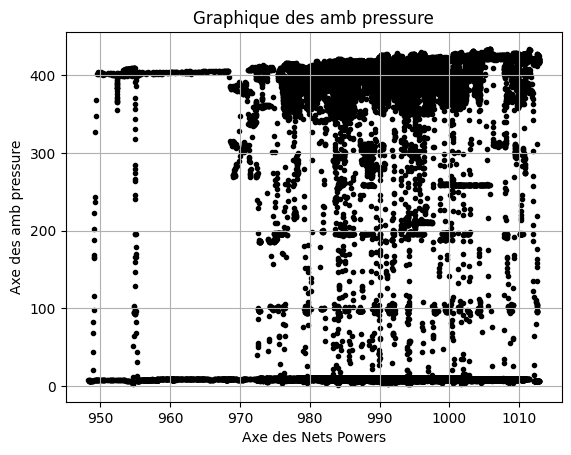

HR %
time
2022-05-25 13:54:00    64.365315
2022-05-17 18:33:00    28.588368
2022-05-20 15:12:00    33.715615
2022-08-11 01:43:00    65.501225
2022-01-23 09:26:00    71.373067
                         ...    
2022-06-24 20:33:00    33.247567
2022-05-09 15:24:00    35.014748
2022-09-09 04:26:00    79.878064
2022-06-21 06:05:00    79.715115
2022-05-17 05:38:00    77.136662
Name: HR %, Length: 75177, dtype: float64 time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64


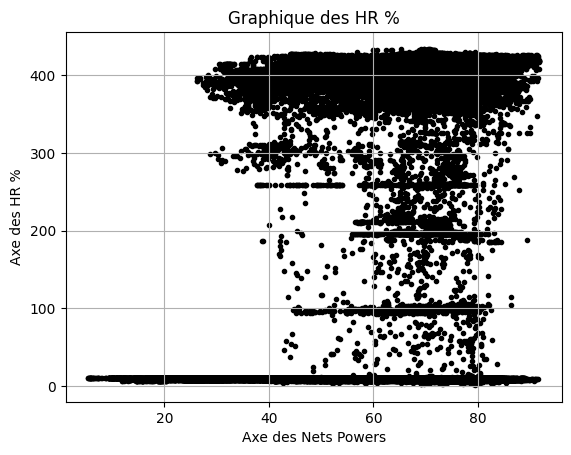

C/H
time
2022-05-25 13:54:00    3.286260
2022-05-17 18:33:00    3.293820
2022-05-20 15:12:00    3.288273
2022-08-11 01:43:00    3.270890
2022-01-23 09:26:00    3.302749
                         ...   
2022-06-24 20:33:00    3.266751
2022-05-09 15:24:00    3.286377
2022-09-09 04:26:00    3.281096
2022-06-21 06:05:00    3.268472
2022-05-17 05:38:00    3.295384
Name: C/H, Length: 75177, dtype: float64 time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64


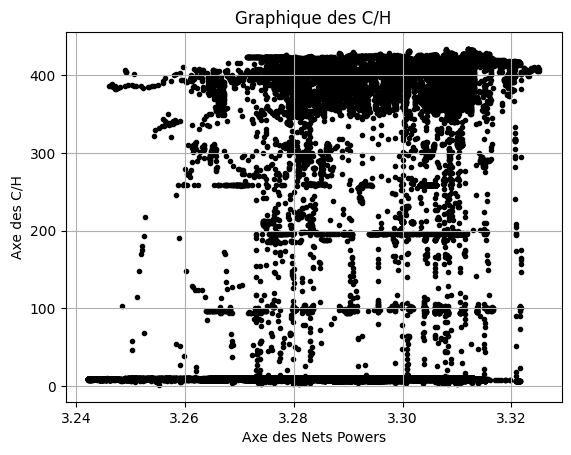

Network Frequency (Hz)
time
2022-05-25 13:54:00    44.767151
2022-05-17 18:33:00    44.793781
2022-05-20 15:12:00    44.783356
2022-08-11 01:43:00    46.299614
2022-01-23 09:26:00    44.800350
                         ...    
2022-06-24 20:33:00    44.779286
2022-05-09 15:24:00    44.781162
2022-09-09 04:26:00    46.270642
2022-06-21 06:05:00    44.787949
2022-05-17 05:38:00    44.799645
Name: Network Frequency (Hz), Length: 75177, dtype: float64 time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64


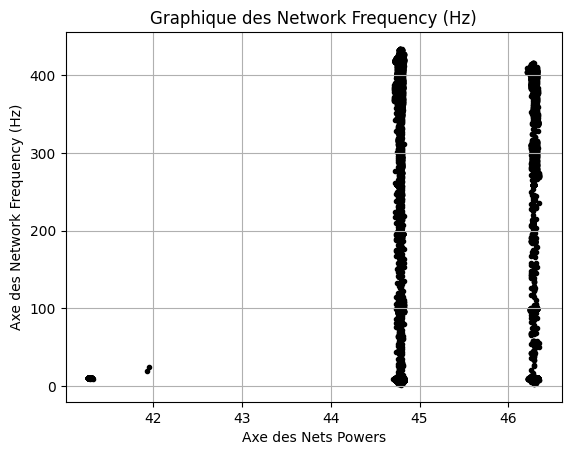

Lower Heating Value (Wh/Nm3)
time
2022-05-25 13:54:00    10772.36380
2022-05-17 18:33:00    10773.74622
2022-05-20 15:12:00    10781.17696
2022-08-11 01:43:00    10743.34102
2022-01-23 09:26:00    10840.63303
                          ...     
2022-06-24 20:33:00    10728.69927
2022-05-09 15:24:00    10726.89806
2022-09-09 04:26:00    10791.39592
2022-06-21 06:05:00    10718.98976
2022-05-17 05:38:00    10751.19434
Name: Lower Heating Value (Wh/Nm3), Length: 75177, dtype: float64 time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64


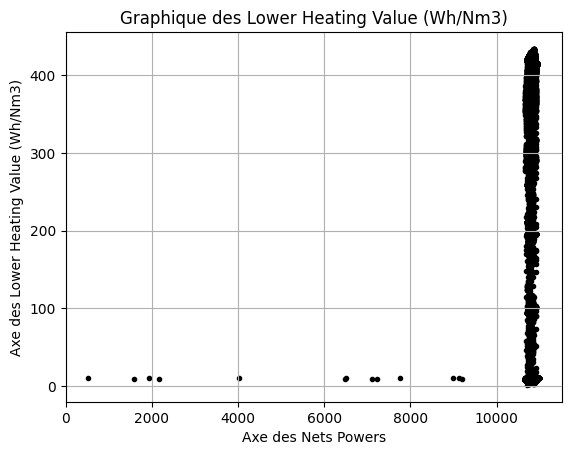

EOH (h)
time
2022-05-25 13:54:00    27019.40142
2022-05-17 18:33:00    27019.40142
2022-05-20 15:12:00    27019.40142
2022-08-11 01:43:00    27314.91900
2022-01-23 09:26:00    25752.16509
                          ...     
2022-06-24 20:33:00    27019.40142
2022-05-09 15:24:00    27019.40142
2022-09-09 04:26:00    27363.69634
2022-06-21 06:05:00    27019.40142
2022-05-17 05:38:00    27019.40142
Name: EOH (h), Length: 75177, dtype: float64 time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64


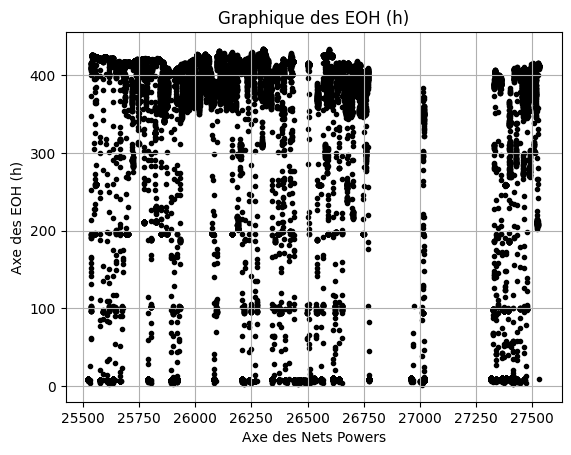

DP filtre
time
2022-05-25 13:54:00    1.565511
2022-05-17 18:33:00    1.570053
2022-05-20 15:12:00    1.547327
2022-08-11 01:43:00    1.605421
2022-01-23 09:26:00    5.718195
                         ...   
2022-06-24 20:33:00    1.564933
2022-05-09 15:24:00    1.430519
2022-09-09 04:26:00    1.581050
2022-06-21 06:05:00    1.567880
2022-05-17 05:38:00    1.569519
Name: DP filtre, Length: 75177, dtype: float64 time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64


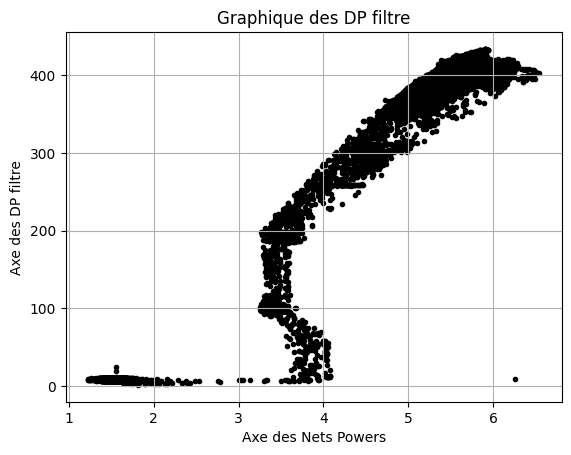

CTRL anti givrage
time
2022-05-25 13:54:00   -13.528621
2022-05-17 18:33:00   -18.706832
2022-05-20 15:12:00   -12.313196
2022-08-11 01:43:00   -18.035989
2022-01-23 09:26:00    -2.145032
                         ...    
2022-06-24 20:33:00   -19.777224
2022-05-09 15:24:00   -17.815417
2022-09-09 04:26:00    -8.672292
2022-06-21 06:05:00   -11.069031
2022-05-17 05:38:00    -9.994857
Name: CTRL anti givrage, Length: 75177, dtype: float64 time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64


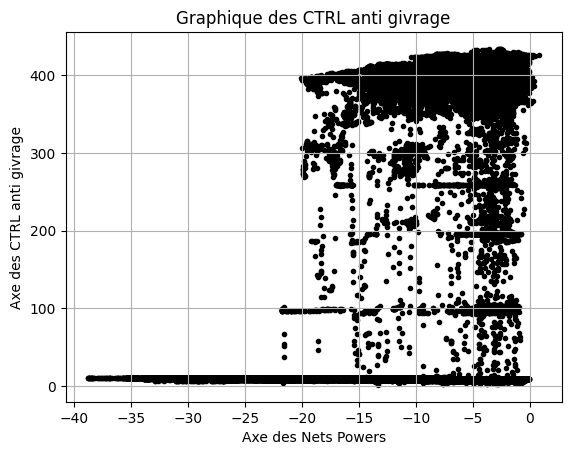

IGV %
time
2022-05-25 13:54:00     -2.744756
2022-05-17 18:33:00     -2.620190
2022-05-20 15:12:00     -2.694407
2022-08-11 01:43:00     -2.768707
2022-01-23 09:26:00    103.752560
                          ...    
2022-06-24 20:33:00     -2.753484
2022-05-09 15:24:00     -2.523461
2022-09-09 04:26:00     -2.562781
2022-06-21 06:05:00     -2.774317
2022-05-17 05:38:00     -2.701924
Name: IGV %, Length: 75177, dtype: float64 time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64


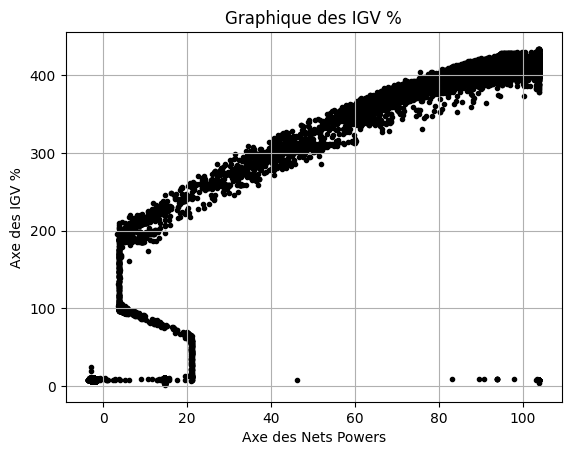

Net Power (MW)
time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64 time
2022-05-25 13:54:00      8.866475
2022-05-17 18:33:00      9.354516
2022-05-20 15:12:00      9.377827
2022-08-11 01:43:00      9.763032
2022-01-23 09:26:00    418.267396
                          ...    
2022-06-24 20:33:00      9.256848
2022-05-09 15:24:00      9.541463
2022-09-09 04:26:00      9.594002
2022-06-21 06:05:00      8.803634
2022-05-17 05:38:00      8.767957
Name: Net Power (MW), Length: 75177, dtype: float64


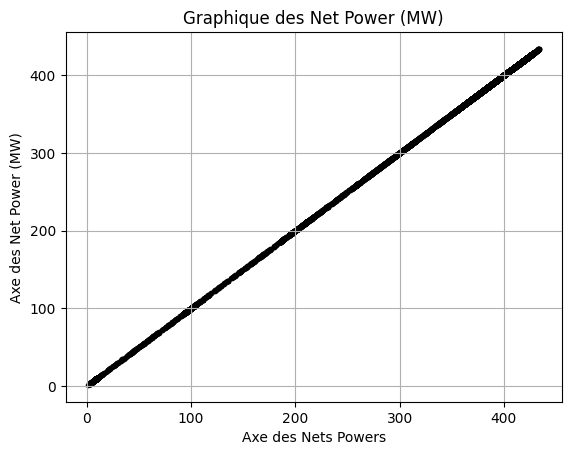

In [4]:
# Vérifier les noms des colonnes pour les index x et y
# Remplacez 'nom_colonne_x' et 'nom_colonne_y' par les noms réels des colonnes que vous voulez utiliser

for col in donnees.columns :
    print(col)
    index_x = donnees[col]
    index_y = donnees['Net Power (MW)']

    print(index_x,index_y)

    
    plt.scatter(index_x, index_y, color='black', marker='.')
    
    plt.xlabel('Axe des Nets Powers')
    plt.ylabel(f'Axe des {col}')
    plt.title(f'Graphique des {col}')
    plt.grid(True)
    plt.show()


In [5]:
# Récupérer la colonne "Net Power (MW)" dans un nouveau DataFrame
donnees_labels = donnees['Net Power (MW)']

predict_label = donnees_test['Net Power (MW)']

# Supprimer la colonne "Net Power (MW)" du DataFrame initial
columns_to_drop = ["amb pressure", "Network Frequency (Hz)", "Lower Heating Value (Wh/Nm3)","Net Power (MW)"]

donnees.drop(columns=columns_to_drop, axis=1, inplace=True)

donnees_test.drop(columns=columns_to_drop, axis=1, inplace=True)

#print(donnees.info(),"\n",donnees_labels.info())


OrderedDict([('fc1.weight', tensor([[-0.3086, -0.0079,  0.2358, -0.0440, -0.0464, -0.2569,  0.1638, -0.0655],
        [-0.1803,  0.0459,  0.0390,  0.1976, -0.2106, -0.1372, -0.0042,  0.2520],
        [-1.2284, -1.5143, -0.9600, -0.9323, -0.9039, -1.3324,  1.3057, -1.2160],
        [-0.2386,  0.0328, -0.2194, -0.1875, -0.1099,  0.2408,  0.3335,  0.0225],
        [-1.3700, -0.8931, -1.3506, -1.4185, -1.1793, -1.0677,  1.4778, -1.0054],
        [ 0.0945, -0.2256,  0.2485, -0.3131, -0.1397, -0.1717,  0.2350, -0.0549],
        [-0.1203,  0.2857, -0.3024,  0.1430, -0.3325, -0.1761, -0.3060, -0.2630],
        [-1.2672, -0.9462, -1.0070, -1.2245, -1.1801, -1.1107,  1.2947, -1.1192]])), ('fc1.bias', tensor([-0.1499, -0.0680, -1.1277, -0.0816, -1.3160,  0.0465,  0.1215, -1.1950])), ('fc2.weight', tensor([[ 0.2522, -0.2485, -0.8531,  0.0229,  1.0627, -0.0718,  0.0346,  1.1615]])), ('fc2.bias', tensor([89.5262]))]) 



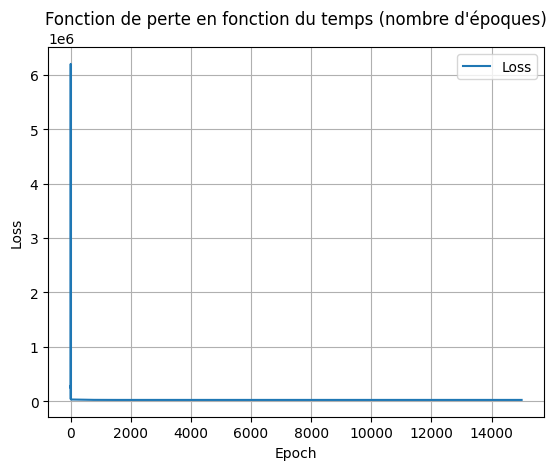

"\n# Mettre le modèle en mode d'évaluation\nmodel.eval()\n\n# Passer les nouvelles données dans le modèle pour obtenir les prédictions\nwith torch.no_grad():\n    predictions = model(predict_tensor)\n\n# Afficher les prédictions\nprint(predictions)\n"

In [6]:
losses = []

# Convertir les données d'entraînement et les étiquettes en tenseurs
train_tensor = torch.tensor(donnees.values, dtype=torch.float32)
train_label_tensor = torch.tensor(donnees_labels.values, dtype=torch.float32)

# Convertir les données de prédiction en tenseur
predict_tensor = torch.tensor(donnees_test.values, dtype=torch.float32)

# Définir le modèle du régresseur simple
class SimpleRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRegressor, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

input_size = donnees.shape[1]
hidden_size = 16
output_size = 1

model = SimpleRegressor(input_size, hidden_size, output_size)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.2)

# Mettre le modèle en mode d'entraînement
model.train()

# Boucle d'entraînement
num_epochs = 200000  # Augmenter le nombre d'époques pour de meilleures performances

for epoch in range(num_epochs):
    # Passer les données dans le modèle
    outputs = model(train_tensor)

    # Calculer la perte
    loss = criterion(outputs.squeeze(), train_label_tensor)

    # Réinitialiser les gradients, effectuer la rétropropagation et mettre à jour les poids
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Afficher la perte à chaque époque
    #print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
    losses.append(loss.item())

model_params = model.state_dict()

print(model_params, "\n")

plt.plot(range(1, num_epochs+1), losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fonction de perte en fonction du temps (nombre d\'époques)')
plt.legend()
plt.grid(True)
plt.show()

"""
# Mettre le modèle en mode d'évaluation
model.eval()

# Passer les nouvelles données dans le modèle pour obtenir les prédictions
with torch.no_grad():
    predictions = model(predict_tensor)

# Afficher les prédictions
print(predictions)
"""


In [7]:
# Charger les données depuis le fichier CSV
# Et le nottoyage de données

chemin_vers_le_fichier = 'test.csv'

test = pd.read_csv(chemin_vers_le_fichier, decimal=',', sep=";", na_values=["#VALEUR!"], index_col="time")
#On remplace les cellules avec des valeurs non valides par NaN

print(test.info())

columns_to_drop = ["amb pressure", "Network Frequency (Hz)", "Lower Heating Value (Wh/Nm3)","Net Power (MW)"]

X_test = test.drop(columns=columns_to_drop, axis=1, inplace=True)


test.index = pd.to_datetime(test.index, format='%d/%m/%Y %H:%M')
#On choisis la date en tant qu'index et on convertis au format spéciale

#recap de la data

assert test.dtypes.equals(pd.Series(dict(zip(test.columns,["float64"]*len(test.columns)))))

print("\n")

test.isna().sum()

#Traitement des NaN on les remplace par la mediane de la collonne. La médiane est une mesure statistique qui représente la valeur centrale d'un ensemble de données triées

chosen_strategy = 'median' # "mean" / "constant" / "most_frequent"

for col in test.columns:
    imp_mean = SimpleImputer(missing_values=np.nan, strategy='median')
    test[col] = imp_mean.fit_transform(test[[col]]).squeeze()

assert (test.isna().sum(axis=0).sum() == 0)

print("\n")

test.isna().sum()

print(test)


<class 'pandas.core.frame.DataFrame'>
Index: 156960 entries, 01/04/2022 00:00 to 31/12/2022 23:59
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Amb temp °C                   156960 non-null  float64
 1   Comp inlet temp °C            156960 non-null  float64
 2   amb pressure                  156960 non-null  float64
 3   HR %                          156960 non-null  float64
 4   C/H                           156960 non-null  float64
 5   Network Frequency (Hz)        156960 non-null  float64
 6   Lower Heating Value (Wh/Nm3)  156960 non-null  float64
 7   EOH (h)                       156960 non-null  float64
 8   DP filtre                     156960 non-null  float64
 9   CTRL anti givrage             156960 non-null  float64
 10  IGV %                         156960 non-null  float64
 11  Net Power (MW)                0 non-null       float64
dtypes: float64(12)
memory us

In [8]:

# Convertir les données d'entraînement en tenseurs
train_tensor = torch.tensor(test.values, dtype=torch.float32)


In [9]:

# Passer les nouvelles données dans le modèle pour obtenir les prédictions
with torch.no_grad():
    predictions = model(train_tensor)

predictions = predictions.numpy().flatten()

df_predictions = pd.DataFrame({
    'time': test.index,
    'Net Power (MW)': predictions,
})

df_predictions.to_csv('predictions.csv', date_format='%d/%m/%Y %H:%M',index=False, sep=';')
df_predictions.head()

,time,Net Power (MW)
0,2022-04-01 00:00:00,89.526176
1,2022-04-01 00:01:00,89.526176
2,2022-04-01 00:02:00,89.526176
3,2022-04-01 00:03:00,89.526176
4,2022-04-01 00:04:00,89.526176
